# Momentum Wind Working Analysis

This analysis notebook should be considered under construction while assumptions are brought up to date, and the model is refined

## TODO List to get this running and accurate

Note: please delete any of the todo items that have been completed, or as they are completed.?

### ORBIT configuration

- [ ] Do we need to consider exclusions in the layout, or anything else that impacts the cable length calculations?
- [ ] Why is the array cable installation failing? (currently skipped)
  - There seems to be an issue with the weather constraints for 10m windspeed <= 25, but the actual windpseeds don't support this error, or at least not seemingly
  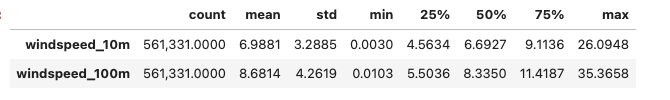

### WOMBAT configuration

- [ ] labor costs need to be recomputed - can use the same
- [ ] Availability of ~97% is quite high, though ~48% net/gross capacity factor is a bit high, though reasonable, so maybe have replacement events with 100% operating reduction to be a bit more realistic `operation_reduction: 1`
- [ ] Can we borrow assumptions from the west coast ports work on the failures, etc.?
  - Aubryn shared a paper with assumptions we should adopt for failures, but they may already exist
  - [ ] Rob: check on this implementation before we implement it ourselves.

### FLORIS configuration

- [ ] Check with Paul Fleming/Patrick Duffy on what model combinations we should really be considering here (remove if that's already happend and I'm out of the loop)

### Financials
- [ ] Update IRR/NPV to properly account for ORBIT cashflow timing

### Results

- See bottom for results gathering format

## Imports and environment set up

In [1]:
from pathlib import Path
from itertools import product

import pandas as pd
import matplotlib.pyplot as plt

from whale import Project

pd.options.display.float_format = '{:,.4f}'.format
pd.options.display.max_columns = 100
pd.options.display.max_rows = 100

## Determine the configurations and create a Project

**NOTE**: Make sure in the WOMBAT config files that the library path is the same that gets printed in this first code block when you run the notebook

In [2]:
library_path = Path("library").resolve()
orbit_config = "Momentum_Wind_base_install.yaml"
wombat_config = "Momentum_Wind_base_operations.yaml"
floris_config = "Momentum_Wind_base_floris_jensen.yaml"

In [3]:
project = Project(

    # Basic Model Configurations
    library_path=library_path,
    weather_profile=library_path / "weather" / "ocean_wind_1_39.0_-74.0_1959_2023.csv",
    orbit_config=orbit_config,
    wombat_config=wombat_config,
    floris_config=floris_config,
    
    # Used for the connecting ORBIT to the weather profile
    orbit_weather_cols=["windspeed_100m", "windspeed_10m", "wave_height"],
    
    # Connecting FLORIS with the weather data and WOMBAT for wind conditions and layout
    floris_windspeed="windspeed_100m",
    floris_wind_direction="wind_direction_100m",
    floris_x_col="floris_x",
    floris_y_col="floris_y",
    
    # Financial Assumptions
    discount_rate=0.025,
    offtake_price=71.60,
    
    # CapEx Date Application Settings
    orbit_start_date="1/1/1998",  # Starting date for installations if set to 0
    # Dates to evenly distribute the varying non-installation CapEx costs per category as
    # (year, month) integer pairs, or a list of tuples, as seen below
    soft_capex_date=(1995, 1), 
    project_capex_date=[(1996, 1), (1996, 7), (1997, 1), (1997, 7)],
    system_capex_date=list(product(range(1996, 2000), (1, 4, 7, 10))), # quarterly over 2 years
    turbine_capex_date=list(product(range(1996, 2000), (1, 4, 7, 10))), # quarterly over 2 years

    # After the first run with a layout file this isn't needed because the default (True) won't fail
    connect_floris_to_layout= True,  # True: connect WOMBAT & FLORIS layout configurations
    connect_orbit_array_design= False,  # True: connect WOMBAT & ORBIT layout configurations
    
)


ORBIT library intialized at 'C:\last_tests\WHaLE\examples\library'


In [4]:
# # Run these for the first iteration only

# # Calculate the relative distance FLORIS layout
# project.generate_floris_positions_from_layout(
#     x_col="easting",
#     y_col="northing",
#     update_config=True,  # update the model and configuration
#     config_fname=floris_config,  # save over the original
# )
# project.connect_floris_to_turbines(x_col="floris_x", y_col="floris_y")

# # Once ORBIT issues are resolved, and feature branch is merged into develop this can be used
# project.connect_orbit_cable_lengths()

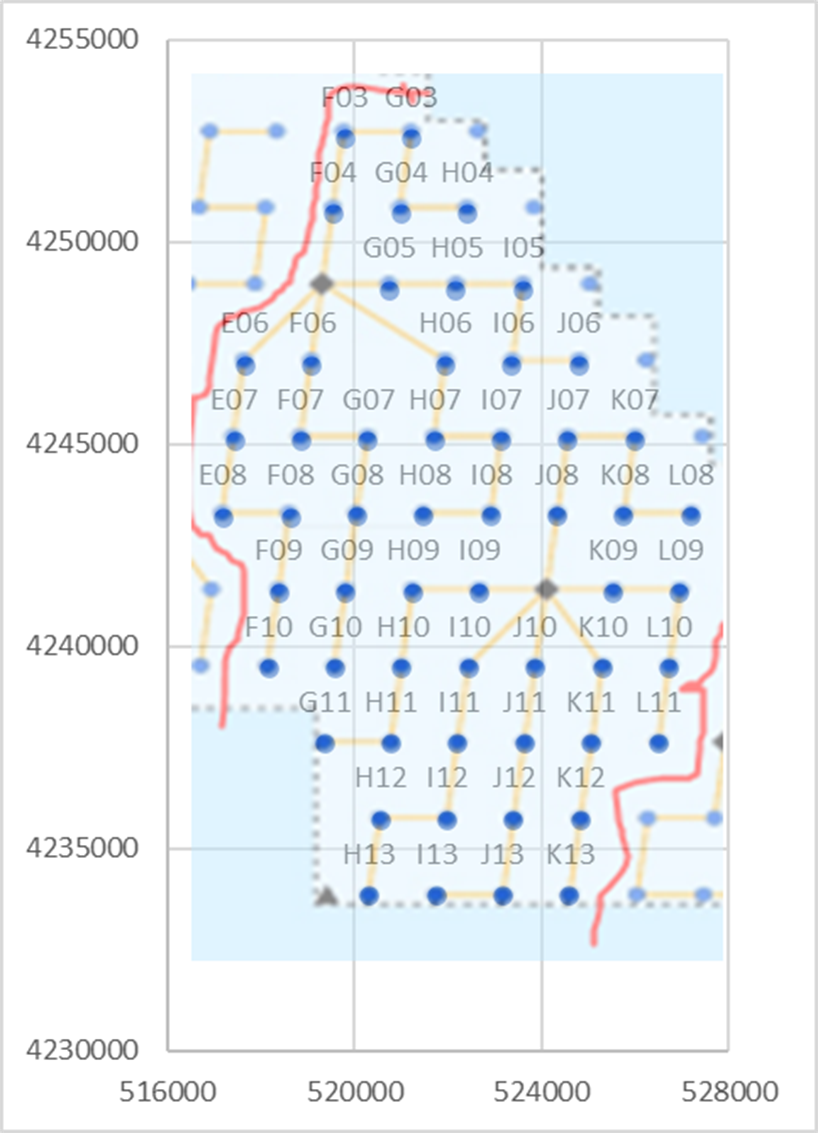

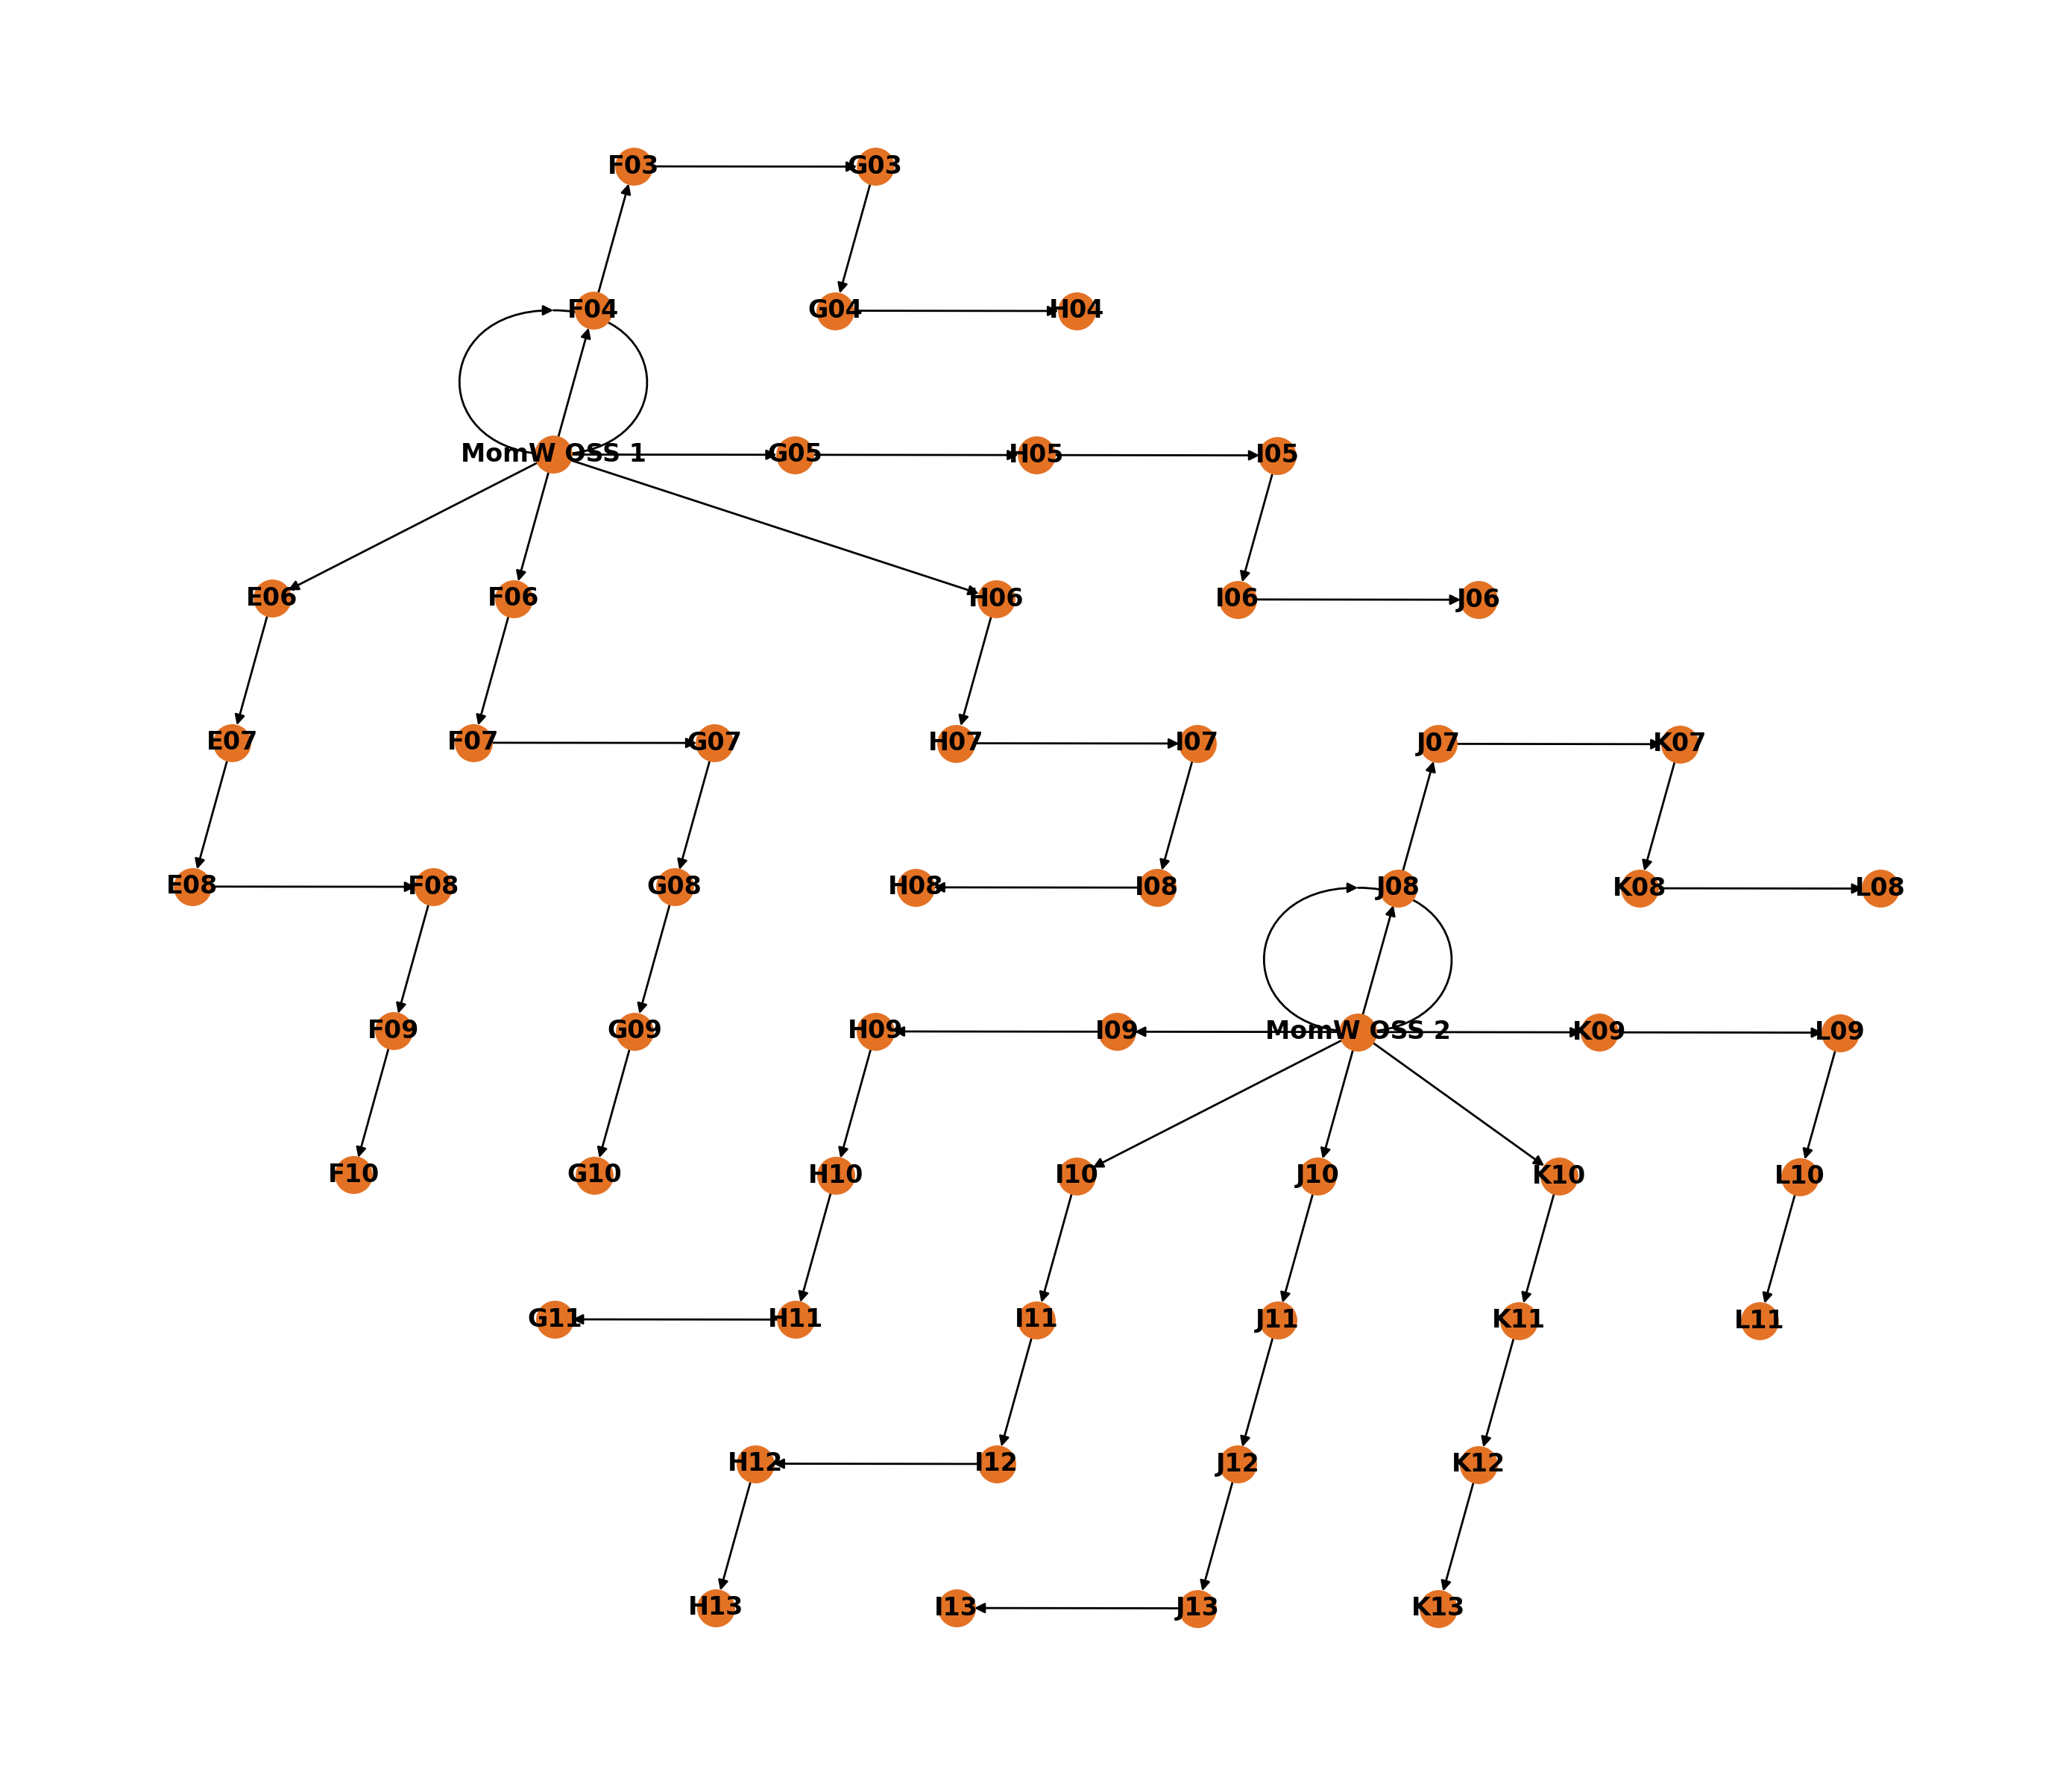

In [5]:
# Inspect the layout
fig, ax = project.plot_farm(return_fig=True)
# fig.savefig(library_path / "results" / "ocean_wind_1_layout.svg")

## Run the analyses and calculate results

This separately calls the `run` methods for each of the ORBIT `ProjectManager` and WOMBAT `Simualation`, in that order. Alternatively, these could just be called on their own, just like we must with FLORIS for the time being.

**NOTE: Array Cable installation is commented out in the configuration for a `StateExhausted` error I can't figure out.**

In [6]:
project.run(
    skip = "orbit",
    which_floris="wind_rose",
    full_wind_rose=False,
    floris_reinitialize_kwargs=dict(cut_in_wind_speed=3.0, cut_out_wind_speed=25.0)
)


Correcting negative Overhang:-2.5
Correcting negative Overhang:-2.5
Correcting negative Overhang:-2.5
Correcting negative Overhang:-2.5
Correcting negative Overhang:-2.5
Correcting negative Overhang:-2.5
Correcting negative Overhang:-2.5
Correcting negative Overhang:-2.5
Correcting negative Overhang:-2.5
Correcting negative Overhang:-2.5
Correcting negative Overhang:-2.5
Correcting negative Overhang:-2.5
Correcting negative Overhang:-2.5


In [7]:
metrics_configuration = {
    "# Turbines": {"metric": "n_turbines", "kwargs": {}},
    "Turbine Rating (MW)": {"metric": "turbine_rating", "kwargs": {}},
    "# OSS": {"metric": "n_substations", "kwargs": {}},
    "Total Export Cable Length (km)": {"metric": "export_system_total_cable_length", "kwargs": {}},
    "Total Array Cable Length (km)": {"metric": "array_system_total_cable_length", "kwargs": {}},
    "CapEx ($)": {"metric": "capex", "kwargs": {}},
    "CapEx per kW ($/kW)": {"metric": "capex", "kwargs": {"per_capacity": "kw"}},
    "OpEx ($)": {"metric": "opex", "kwargs": {}},
    "OpEx per kW ($/kW)": {"metric": "opex", "kwargs": {"per_capacity": "kw"}},
    "AEP (MWh)": {"metric": "energy_production", "kwargs": {}},
    "AEP per kW (MWh/kW)": {"metric": "energy_production", "kwargs": {"per_capacity": "kw"}},
    "LCOE ($/MWh)": {"metric": "lcoe", "kwargs": {}},
    "IRR ($)": {"metric": "irr", "kwargs": {}},
    "NPV ($)": {"metric": "npv", "kwargs": {}},
}

report_df = project.generate_report(metrics_configuration, "Momentum Wind")
report_df.T.to_csv(library_path / "results" / "Momentum_Wind_metrics.csv")

KeyError: 'OffshoreSubstationDesign'

## Results

This dataframe can be appended to an existing results file if desired, as long as the column naming conventions remain the same across projects.

In [ ]:
report_df

In [ ]:
report_df.T